# 🧬 K-Nearest Neighbors — Breast Cancer Classification
Self-contained pipeline with k hyperparameter tuning.


In [1]:
# ============================================================
# Setup
# ============================================================
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_curve, auc)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.dpi"] = 110
%matplotlib inline

# ============================================================
# Load Wisconsin Breast Cancer dataset (UCI open database)
# 30 cell-nucleus image features; target 0=malignant, 1=benign
# ============================================================
cancer = load_breast_cancer(as_frame=True)
df = cancer.frame
X = cancer.data
y = cancer.target
feature_names = list(cancer.feature_names)
print(f"Dataset shape: {df.shape}  |  Classes: {np.bincount(y).tolist()} "
      "(0=malignant, 1=benign)")
print(f"Missing values: {df.isna().sum().sum()}")

# ============================================================
# Preprocessing — stratified split + StandardScaler (fit on train only)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")


Dataset shape: (569, 31)  |  Classes: [212, 357] (0=malignant, 1=benign)
Missing values: 0
Train: 455 | Test: 114


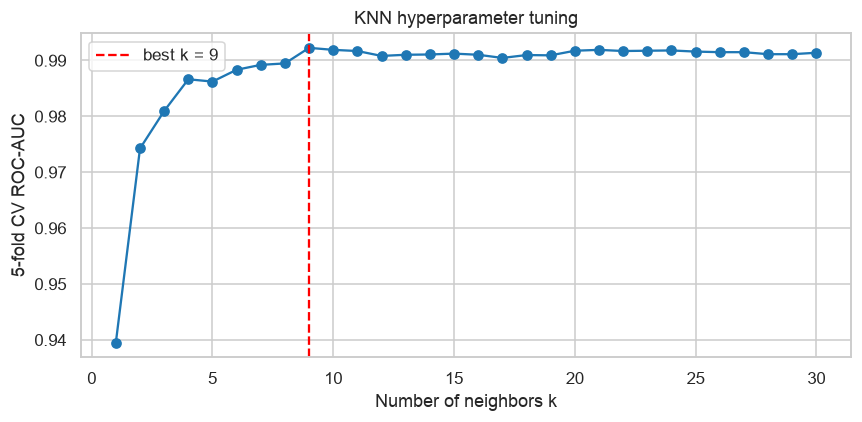

In [2]:
from sklearn.neighbors import KNeighborsClassifier

# ============================================================
# Hyperparameter tuning — number of neighbors k
# ============================================================
k_range = range(1, 31)
cv_knn = []
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_sc, y_train, cv=5, scoring="roc_auc")
    cv_knn.append(scores.mean())
best_k = k_range[np.argmax(cv_knn)]

plt.figure(figsize=(8, 4))
plt.plot(k_range, cv_knn, "o-", color="#1f77b4")
plt.axvline(best_k, color="red", ls="--", label=f"best k = {best_k}")
plt.xlabel("Number of neighbors k"); plt.ylabel("5-fold CV ROC-AUC")
plt.title("KNN hyperparameter tuning"); plt.legend()
plt.tight_layout(); plt.show()

model = KNeighborsClassifier(n_neighbors=best_k)


Test  accuracy : 0.9737  |  precision: 0.9600
Recall         : 1.0000  |  F1      : 0.9796
Test  ROC-AUC  : 0.9944
CV    ROC-AUC  : 0.9929 ± 0.0063


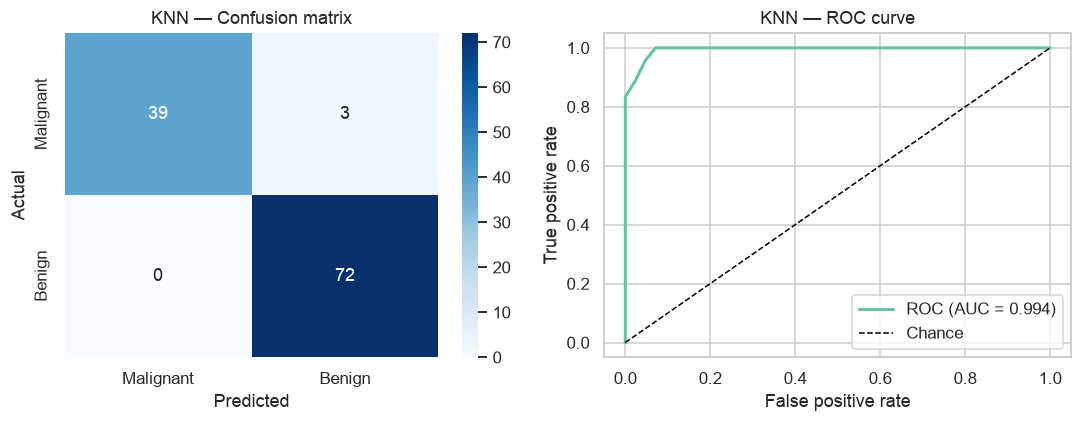

In [3]:
# ============================================================
# Train KNN & evaluate
# ============================================================
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train_sc, y_train)
y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
cv_scores = cross_val_score(model, X_train_sc, y_train,
                            cv=StratifiedKFold(5, shuffle=True, random_state=42),
                            scoring="roc_auc")

print(f"Test  accuracy : {acc:.4f}  |  precision: {prec:.4f}")
print(f"Recall         : {rec:.4f}  |  F1      : {f1:.4f}")
print(f"Test  ROC-AUC  : {roc_auc:.4f}")
print(f"CV    ROC-AUC  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Malignant", "Benign"], yticklabels=["Malignant", "Benign"])
axes[0].set_title("KNN — Confusion matrix")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")
axes[1].plot(fpr, tpr, lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
axes[1].set_xlabel("False positive rate"); axes[1].set_ylabel("True positive rate")
axes[1].set_title("KNN — ROC curve")
axes[1].legend(loc="lower right")
plt.tight_layout(); plt.show()
